## Recoverability of held-out states under synchronous simulation

Structural preservation of the influence graph ensemble is one measure of robustness. A complementary
question is whether the models inferred under partial observations can actively **recover the held-out
state**, that is, whether simulating a BN from the state immediately preceding the missing
observation reproduces the correct value at that time point.

For each holdout condition, we simulate every BN in the partial-observation ensemble forward by
**one synchronous step** from the last known state, and check whether the result matches the
held-out observation. This tests the fast $L \to R$ step for receptor holdouts (given the correct
ligand context, do the inferred receptor rules fire correctly?) and the slow $R \to L$ step for
ligand holdouts (given the correct receptor context, do the inferred ligand rules produce the right
secretion state?).

Concretely, for a holdout at time point $T_i$:

- **Initial state**: the last fully observed state before $T_i$
- **Target state**: the held-out observation at $T_i$ (taken from the complete dataset for evaluation)
- **Test**: does one synchronous simulation step from the initial state reach the target?

The recoverability rate, the fraction of models in the ensemble that pass this test — directly
reflects how well the remaining observations constrain the inferred rules for the held-out variables.

In [29]:
from Inference_CCC import *

### Generate full observations, to compare to the PSS partial observation 

In [30]:
# Complete observations with one state changed at each time step
R_A = {
        'T1': {'R1_A': 1, 'R2_A': 0},
        'T2': {'R1_A': 1, 'R2_A': 0},
        'T3': {'R1_A': 1, 'R2_A': 1},
        'T4': {'R1_A': 1, 'R2_A': 1},
        'T5': {'R1_A': 0, 'R2_A': 1},
        'T6': {'R1_A': 0, 'R2_A': 1},
        'T7': {'R1_A': 0, 'R2_A': 1},
        'T8': {'R1_A': 0, 'R2_A': 1}
    }

R_B = {
        'T1': {'R1_B': 1, 'R2_B': 0},
        'T2': {'R1_B': 1, 'R2_B': 0},
        'T3': {'R1_B': 0, 'R2_B': 1},
        'T4': {'R1_B': 0, 'R2_B': 1},
        'T5': {'R1_B': 0, 'R2_B': 0},
        'T6': {'R1_B': 0, 'R2_B': 0},
        'T7': {'R1_B': 1, 'R2_B': 1},
        'T8': {'R1_B': 1, 'R2_B': 1}
    }

L_A = {
        'T1': {'L1_A': 1, 'L2_A': 0, 'L3_A': 0, 'L4_A': 0},
        'T2': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T3': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T4': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T5': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T6': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T7': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T8': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1}
    }

L_B = {
        'T1': {'L1_B': 1, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T2': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T3': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T4': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T5': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T6': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T7': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T8': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 1}
    }

R = {"A": R_A, "B": R_B}
L = {"A": L_A, "B": L_B}

# Create the observation data
obs_df, complete_compr_obs_df, cells, influences, all_receptors, all_ligands = create_observation_data(R, L)

In [31]:
complete_compr_obs_df 

,R1_A,R2_A,R1_B,R2_B,L1_A,L2_A,L3_A,L4_A,L1_B,L2_B,L3_B,L4_B
T1,1,0,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
T2,1,1,0,1,1,1,0,0,1,1,0,0
T3,0,1,0,0,1,1,1,0,0,0,1,0
T4,0,1,1,1,0,0,0,1,0,0,0,0
T5,<NA>,<NA>,<NA>,<NA>,0,0,0,1,0,0,0,1


In [32]:
results_complete_obs = run_full_workflow(complete_compr_obs_df, cells, influences, limit_igs=500, limit_bns=0, details=False)

Enumerating up to 500 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...

Enumerating IG+BN pairs: 1it [00:00,  2.32it/s]

done in 0.2s


Enumerating IG+BN pairs: 448it [00:02, 204.51it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [48]:
limit_igs = 1000
limit_bns = 0

# Introducing missing information in the observations

For each PSS, either the receptors or the ligands information is taken off form the observations (compr_obs_df) and the inference is done with it. \
The influence graphs are plotted, and then compared to the ones obtained with all observations 

## In the receptors

### R(T2) is held out 

In [49]:
tp_removed = 'T2'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT2_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 896it [00:03, 260.97it/s]

Found 896 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 896 Boolean networks

    Number of functions, inferred with all observations : 896
    Number of influence graphs, inferred with all observations: 896
            


In [50]:
# Taken off :  R_T2 = compr_obs_df.loc[tp_removed, r_cols].to_dict()

# Init
R_T1 = compr_obs_df.loc["T1", r_cols].to_dict()
L_T2 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Test
R_T2 = complete_compr_obs_df.loc[tp_removed, r_cols].to_dict()
L_T1 = complete_compr_obs_df.loc["T1", l_cols].to_dict()

initial_state = {**R_T1, **L_T2}
target_state = {**R_T2, **L_T2}
max_steps = 1

passed_RT2 = 0
for _, model_row in results_RT2_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_RT2 += 1

print(f"{passed_RT2}/{len(results_RT2_missing['bns'])} models pass ({100*passed_RT2/len(results_RT2_missing['bns']):.1f}%)")

448/896 models pass (50.0%)


### R(T3) is help out

In [51]:
tp_removed = 'T3'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT3_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:01, 232.86it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [52]:
# Taken off :  R_T3 = compr_obs_df.loc[tp_removed, r_cols].to_dict()

# Init
R_T2 = compr_obs_df.loc["T2", r_cols].to_dict()
L_T3 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Test
R_T3 = complete_compr_obs_df.loc[tp_removed, r_cols].to_dict()
L_T2 = complete_compr_obs_df.loc["T2", l_cols].to_dict()

initial_state = {**R_T2, **L_T3}
target_state = {**R_T3, **L_T3}
max_steps = 1

passed_RT3 = 0
for _, model_row in results_RT3_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_RT3 += 1

print(f"{passed_RT3}/{len(results_RT3_missing['bns'])} models pass ({100*passed_RT3/len(results_RT3_missing['bns']):.1f}%)")

448/448 models pass (100.0%)


### R(T4) is help out

In [53]:
tp_removed = 'T4'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT4_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)


Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:02, 212.76it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [54]:
# Taken off :  R_T4 = compr_obs_df.loc[tp_removed, r_cols].to_dict()

# Init
R_T3 = compr_obs_df.loc["T3", r_cols].to_dict()
L_T4 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Test
R_T4 = complete_compr_obs_df.loc[tp_removed, r_cols].to_dict()
L_T3 = complete_compr_obs_df.loc["T3", l_cols].to_dict()

initial_state = {**R_T3, **L_T4}
target_state = {**R_T4, **L_T4}
max_steps = 1

passed_RT4 = 0
for _, model_row in results_RT4_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_RT4 += 1

print(f"{passed_RT4}/{len(results_RT4_missing['bns'])} models pass ({100*passed_RT4/len(results_RT4_missing['bns']):.1f}%)")

448/448 models pass (100.0%)


## In the ligands

### L(T3) is held out

In [55]:
tp_removed = 'T3'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT3_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 1000it [00:04, 212.25it/s]

Found 1000 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 1000 Boolean networks

    Number of functions, inferred with all observations : 1000
    Number of influence graphs, inferred with all observations: 1000
            


In [56]:
# Taken off :  L_T3 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Init
R_T2 = compr_obs_df.loc["T2", r_cols].to_dict()
L_T2 = compr_obs_df.loc["T2", l_cols].to_dict()

# Test
L_T3 = complete_compr_obs_df.loc[tp_removed, l_cols].to_dict()

initial_state = {**R_T2, **L_T2}
target_state = {**R_T2, **L_T3}
max_steps = 1

passed_LT3 = 0
for _, model_row in results_LT3_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_LT3 += 1

print(f"{passed_LT3}/{len(results_LT3_missing['bns'])} models pass ({100*passed_LT3/len(results_LT3_missing['bns']):.1f}%)")

0/1000 models pass (0.0%)


### L(T4) is held out 

In [57]:
tp_removed = 'T4'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT4_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 936it [00:04, 209.24it/s]


Found 936 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 936 Boolean networks

    Number of functions, inferred with all observations : 936
    Number of influence graphs, inferred with all observations: 936
            


In [58]:
# Taken off :  L_T4 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Init
R_T3 = compr_obs_df.loc["T3", r_cols].to_dict()
L_T3 = compr_obs_df.loc["T3", l_cols].to_dict()

# Test
L_T4 = complete_compr_obs_df.loc[tp_removed, l_cols].to_dict()

initial_state = {**R_T3, **L_T3}
target_state = {**R_T3, **L_T4}
max_steps = 1

passed_LT4 = 0
for _, model_row in results_LT4_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_LT4 += 1

print(f"{passed_LT4}/{len(results_LT4_missing['bns'])} models pass ({100*passed_LT4/len(results_LT4_missing['bns']):.1f}%)")

18/936 models pass (1.9%)


### L(T5) is held out

In [59]:
tp_removed = 'T5'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT5_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:01, 235.06it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [60]:
# Taken off :  L_T5 = compr_obs_df.loc[tp_removed, l_cols].to_dict()

# Init
R_T4 = compr_obs_df.loc["T4", r_cols].to_dict()
L_T4 = compr_obs_df.loc["T4", l_cols].to_dict()

# Test
L_T5 = complete_compr_obs_df.loc[tp_removed, l_cols].to_dict()

initial_state = {**R_T4, **L_T4}
target_state = {**R_T4, **L_T5}
max_steps = 1

passed_LT5 = 0
for _, model_row in results_LT5_missing["bns"].iterrows():
    bn = minibn.BooleanNetwork(model_row.to_dict())
    sim_states = list(minibn.SyncRun(bn, initial_state, max_steps))
    if sim_states[-1] == target_state:
        passed_LT5 += 1

print(f"{passed_LT5}/{len(results_LT5_missing['bns'])} models pass ({100*passed_LT5/len(results_LT5_missing['bns']):.1f}%)")

0/448 models pass (0.0%)


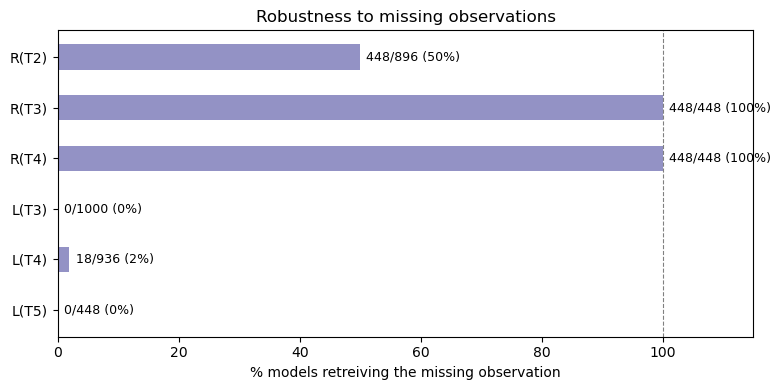

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Data ---
conditions = {
    'R(T2)':      {'passed': passed_RT2,        'total': len(results_RT2_missing['bns']),   'type': 'R'},
    'R(T3)':      {'passed': passed_RT3,        'total': len(results_RT3_missing['bns']),   'type': 'R'},
    'R(T4)':      {'passed': passed_RT4,        'total': len(results_RT4_missing['bns']),   'type': 'R'},
    'L(T3)':      {'passed': passed_LT3,        'total': len(results_LT3_missing['bns']),   'type': 'L'},
    'L(T4)':      {'passed': passed_LT4,        'total': len(results_LT4_missing['bns']),   'type': 'L'},
    'L(T5)':      {'passed': passed_LT5,        'total': len(results_LT5_missing['bns']),   'type': 'L'},
}

#colors = { 'R': "#0e0d0d", 'L': "#0e0d0d"}

colors = { 'R': "#9392C5", 'L': "#9392C5"}



labels, pcts, bar_colors, totals = [], [], [], []
for name, d in conditions.items():
    labels.append(name)
    pct = 100 * d['passed'] / d['total'] if d['total'] > 0 else 0
    pcts.append(pct)
    bar_colors.append(colors[d['type']])
    totals.append(d)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(labels, pcts, color=bar_colors, height=0.5)

for bar, d in zip(bars, totals):
    pct = 100 * d['passed'] / d['total'] if d['total'] > 0 else 0
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{d['passed']}/{d['total']} ({pct:.0f}%)",
            va='center', fontsize=9)

ax.set_xlim(0, 115)
ax.set_xlabel('% models retreiving the missing observation')
ax.set_title('Robustness to missing observations')
ax.axvline(100, color='gray', linestyle='--', linewidth=0.8)
ax.invert_yaxis()


plt.tight_layout()
plt.show()